In [212]:
import pandas as pd
import numpy as np


In [213]:
df = pd.read_csv('/content/titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [215]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [216]:
df.duplicated().sum()

0

In [217]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [218]:
len(df.Ticket.unique())

681

In [219]:
## Notes

# missing values
# 1) Age 714/891 -> 891-714 missing values
# 2) Cabin 204/891 -> 891-204 missing values
# 3) Embarked 889/891 -> 891-889 missing values

# There are no duplicated values
# Features that can be dropped: PassengerID, Name, Ticket


In [220]:
numerical_df = df.select_dtypes(include='number')
numerical_df = numerical_df [['Age','Fare']]
numerical_df.head(1)

,Age,Fare
0,22.0,7.25


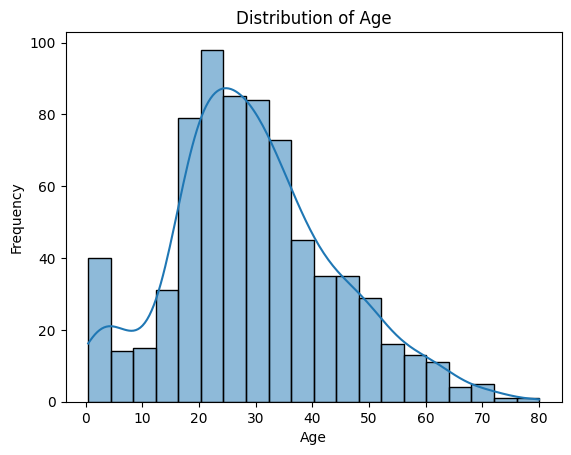

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Age'], bins=20, kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

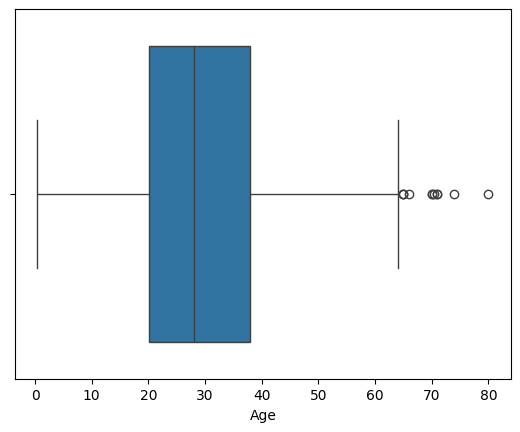

In [222]:
sns.boxplot(x=df['Age'])
plt.show()

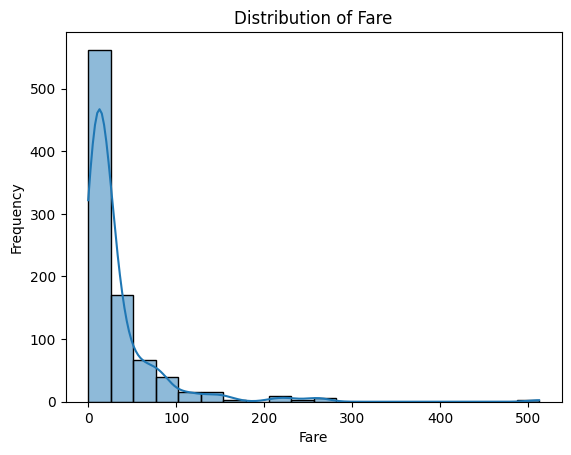

In [223]:
# For Fare
sns.histplot(df['Fare'], bins=20, kde=True)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Distribution of Fare')
plt.show()

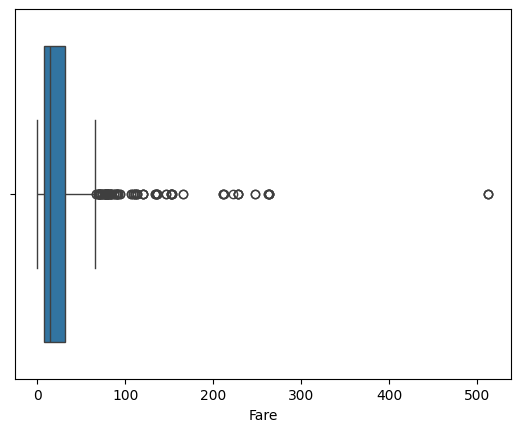

In [224]:
sns.boxplot(x=df['Fare'])
plt.show()

In [225]:
correlation = df['Age'].corr(df['Fare'])
correlation

0.0960666917690389

In [226]:
# Numerical analysis
# Age having values less than 1 may be a problem
# about 7 outliers whome ages are more than 60
# Fare feature is skewed to the right, so there are some outliers

In [227]:
categorical_df = df.select_dtypes(include=['object', 'category'])
categorical_df['SibSp'] = df['SibSp']
categorical_df['Parch'] = df['Parch']
categorical_df['Pclass'] = df['Pclass']
categorical_df = categorical_df[["Sex","Cabin", "Embarked","SibSp","Parch","Pclass"]]
categorical_df

,Sex,Cabin,Embarked,SibSp,Parch,Pclass
0,male,NaN,S,1,0,3
1,female,C85,C,1,0,1
2,female,NaN,S,0,0,3
3,female,C123,S,1,0,1
4,male,NaN,S,0,0,3
...,...,...,...,...,...,...
886,male,NaN,S,0,0,2
887,female,B42,S,0,0,1
888,female,NaN,S,1,2,3
889,male,C148,C,0,0,1


In [228]:
for column in categorical_df.columns:
    print(f"Unique values in column '{column}':")
    print(categorical_df[column].value_counts())
    print()

Unique values in column 'Sex':
Sex
male      577
female    314
Name: count, dtype: int64

Unique values in column 'Cabin':
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

Unique values in column 'Embarked':
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Unique values in column 'SibSp':
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Unique values in column 'Parch':
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Unique values in column 'Pclass':
Pclass
3    491
1    216
2    184
Name: count, dtype: int64



In [229]:
# Parch and SibSp -> biased towrds 0

In [230]:
## Results

# missing values
# 1) Age 714/891 -> 891-714 missing values
# 2) Cabin 204/891 -> 891-204 missing values
# 3) Embarked 889/891 -> 891-889 missing values

# There are no duplicated values
# Features that can be dropped: PassengerID, Name, Ticket

# Numerical analysis
# Age having values less than 1 may be a problem
# about 7 outliers whome ages are more than 60
# Fare feature is skewed to the right, so there are some outliers

# For categorical data
# Parch and SibSp -> biased towrds 0


In [231]:
#######

In [232]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [233]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [234]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [235]:
df.drop(columns=['Cabin'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [236]:
#Split the data before any data preprocessing to prevent any data leakage...

from sklearn.model_selection import train_test_split



train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_median_age = train_df['Age'].median()
train_median_Fare = train_df['Fare'].median()

train_df['Age'] = train_df['Age'].fillna(train_median_age)
train_df['Fare'] = train_df['Fare'].fillna(train_median_Fare)

test_median_age = test_df['Age'].median()
test_median_Fare = test_df['Fare'].median()

test_df['Age'] = test_df['Age'].fillna(test_median_age)
test_df['Fare'] = test_df['Fare'].fillna(test_median_Fare)




In [237]:
#For categorical data

train_mode_Embarked = train_df['Embarked'].mode()[0]
test_mode_Embarked = test_df['Embarked'].mode()[0]

train_df['Embarked'] = train_df['Embarked'].fillna(train_mode_Embarked)
test_df['Embarked'] = test_df['Embarked'].fillna(test_mode_Embarked)



In [238]:
train_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [239]:
# Pclass	SibSp	Parch -> label encoding
# Sex Embarked -> one hot encoding

In [240]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = ['Pclass', 'SibSp', 'Parch']

for col in label_cols:
    le.fit(train_df[col])
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

onehot_cols = ['Sex', 'Embarked']

train_df_onehot = pd.get_dummies(train_df, columns=onehot_cols)
test_df_onehot = pd.get_dummies(test_df, columns=onehot_cols)

In [241]:
train_df_onehot.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,0,0,45.5,0,0,28.5000,False,True,False,False,True
733,0,1,23.0,0,0,13.0000,False,True,False,False,True
382,0,2,32.0,0,0,7.9250,False,True,False,False,True
704,0,2,26.0,1,0,7.8542,False,True,False,False,True
813,0,2,6.0,4,2,31.2750,True,False,False,False,True


In [242]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


scale_cols = ['Age', 'Fare']

scaler.fit(train_df_onehot[scale_cols])

train_df_onehot[scale_cols] = scaler.transform(train_df_onehot[scale_cols])
test_df_onehot[scale_cols] = scaler.transform(test_df_onehot[scale_cols])

In [243]:
train_df_onehot

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,0,0,0.566474,0,0,0.055628,False,True,False,False,True
733,0,1,0.283740,0,0,0.025374,False,True,False,False,True
382,0,2,0.396833,0,0,0.015469,False,True,False,False,True
704,0,2,0.321438,1,0,0.015330,False,True,False,False,True
813,0,2,0.070118,4,2,0.061045,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
106,1,2,0.258608,0,0,0.014932,True,False,False,False,True
270,0,0,0.346569,0,0,0.060508,False,True,False,False,True
860,0,2,0.509927,2,0,0.027538,False,True,False,False,True
435,1,0,0.170646,1,2,0.234224,True,False,False,False,True


In [244]:
X_train = train_df_onehot.drop('Survived',axis=1)
y_train = train_df_onehot['Survived']

X_test = test_df_onehot.drop('Survived',axis=1)
y_test = test_df_onehot['Survived']


In [245]:
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,0,0.566474,0,0,0.055628,False,True,False,False,True
733,1,0.283740,0,0,0.025374,False,True,False,False,True
382,2,0.396833,0,0,0.015469,False,True,False,False,True
704,2,0.321438,1,0,0.015330,False,True,False,False,True
813,2,0.070118,4,2,0.061045,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
106,2,0.258608,0,0,0.014932,True,False,False,False,True
270,0,0.346569,0,0,0.060508,False,True,False,False,True
860,2,0.509927,2,0,0.027538,False,True,False,False,True
435,0,0.170646,1,2,0.234224,True,False,False,False,True


In [246]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [247]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

#Instantiate the SVM model
svm_model = SVC()

#Train the model on the training data
svm_model.fit(X_train, y_train)

#Make predictions on the test data
y_pred = svm_model.predict(X_test)

#Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)


print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[93 12]
 [24 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       105
           1       0.81      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [248]:
help(svm_model)

Help on SVC in module sklearn.svm._classes object:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)
 |  
 |  C-Support Vector Classification.
 |  
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |  
 |  The multiclass support is handled according to a one-vs-one scheme.
 |  
 |  For details on the precise mathematical formulation of the provided
 |  kernel functions and how `

In [249]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],           # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],    # Kernel types
    'gamma': ['scale', 'auto'],             # Kernel coefficient
    'degree': [2, 3, 4],                    # For 'poly' kernel
}

# Set up the Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=5)

# Fit the model on training data
grid_search.fit(X_train, y_train)

# Best parameters and model
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best score:", best_score)

# Retrieve the best model
best_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_model.predict(X_test)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Best Parameters: {'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Best score: 0.8272333300502315
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       105
           1       0.86      0.68      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.82      0.82       179

Confusion Matrix:
[[97  8]
 [24 50]]


In [250]:

median_age = df['Age'].median()
median_Fare = df['Fare'].median()

df['Age'] = df['Age'].fillna(median_age)
df['Fare'] = df['Fare'].fillna(median_Fare)

median_age = df['Age'].median()
median_Fare = df['Fare'].median()

mode_Embarked = df['Embarked'].mode()[0]
mode_Embarked = df['Embarked'].mode()[0]

df['Embarked'] = df['Embarked'].fillna(mode_Embarked)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = ['Pclass', 'SibSp', 'Parch']

for col in label_cols:
    le.fit(df[col])
    df[col] = le.transform(df[col])


onehot_cols = ['Sex', 'Embarked']

df_onehot = pd.get_dummies(df, columns=onehot_cols)





In [251]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


scale_cols = ['Age', 'Fare']

scaler.fit(df_onehot[scale_cols])

df_onehot[scale_cols] = scaler.transform(df_onehot[scale_cols])



In [252]:
df_onehot

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,2,0.271174,1,0,0.014151,False,True,False,False,True
1,1,0,0.472229,1,0,0.139136,True,False,True,False,False
2,1,2,0.321438,0,0,0.015469,True,False,False,False,True
3,1,0,0.434531,1,0,0.103644,True,False,False,False,True
4,0,2,0.434531,0,0,0.015713,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,1,0.334004,0,0,0.025374,False,True,False,False,True
887,1,0,0.233476,0,0,0.058556,True,False,False,False,True
888,0,2,0.346569,1,2,0.045771,True,False,False,False,True
889,1,0,0.321438,0,0,0.058556,False,True,True,False,False


In [253]:
X = df_onehot.drop('Survived',axis=1)
y = df_onehot['Survived']




In [254]:
svm_model = SVC(C=100, degree=2, gamma='scale')
svm_model.fit(X, y)

SVC(C=100, degree=2)

In [255]:
y_pred = best_model.predict(X_test)


Accuracy: 0.8212290502793296
Confusion Matrix:
[[97  8]
 [24 50]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       105
           1       0.86      0.68      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.82      0.82       179



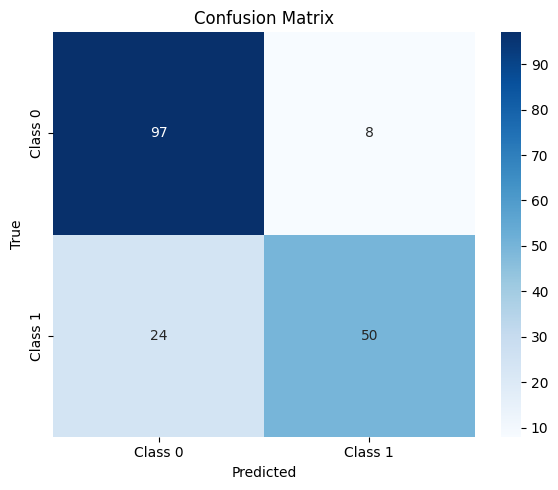

In [256]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

# Classification Report
report = classification_report(y_test, y_pred)
print(f"Classification Report:\n{report}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()

# Displaying the plot
plt.show()


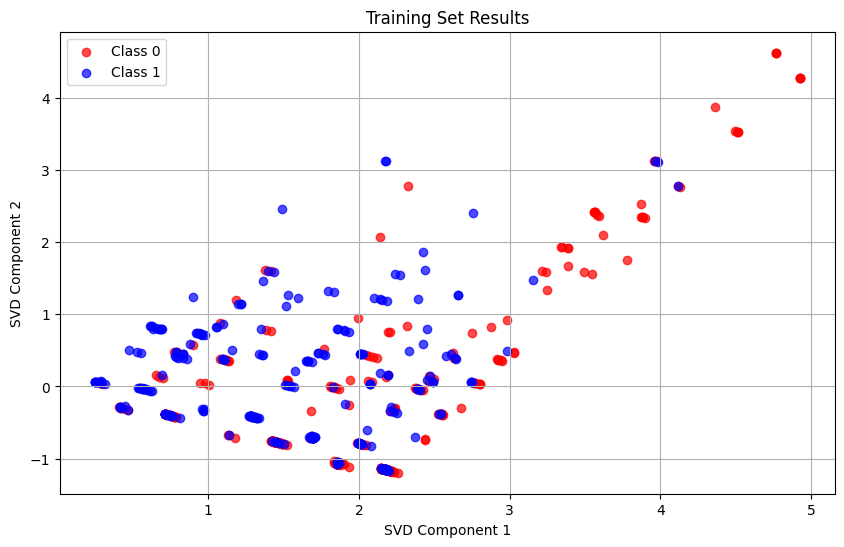

In [257]:
from sklearn.decomposition import TruncatedSVD

# Apply TruncatedSVD to reduce dimensionality to 2D for visualization
svd = TruncatedSVD(n_components=2)
X_train_svd = svd.fit_transform(X_train)

# Plotting the training set results
plt.figure(figsize=(10, 6))
for label, color in zip(np.unique(y_train), ["red", "blue"]):
    plt.scatter(
        X_train_svd[y_train == label, 0],
        X_train_svd[y_train == label, 1],
        c=color,
        label=f"Class {label}",
        alpha=0.7,
    )
plt.title("Training Set Results")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.grid()
plt.show()

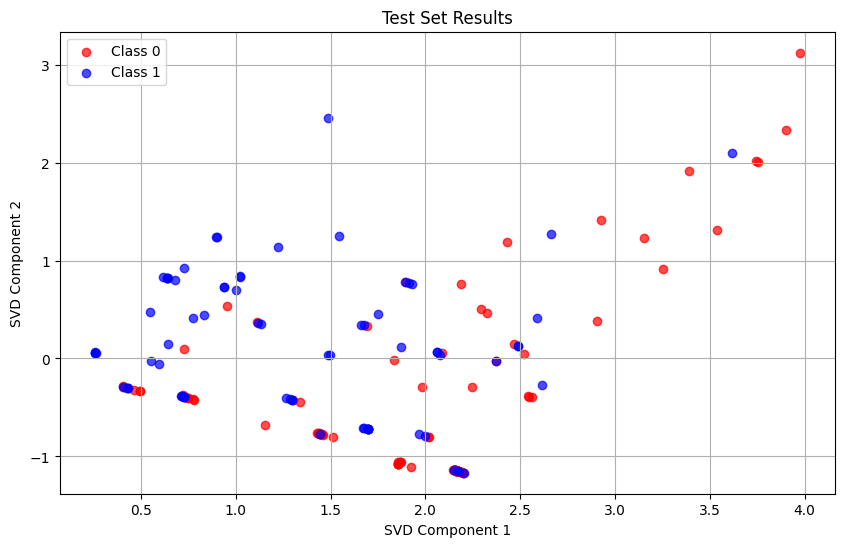

In [258]:
# Apply TruncatedSVD to the test set for visualization
X_test_svd = svd.transform(X_test)

# Plotting the test set results
plt.figure(figsize=(10, 6))
for label, color in zip(np.unique(y_test), ["red", "blue"]):
    plt.scatter(
        X_test_svd[y_test == label, 0],
        X_test_svd[y_test == label, 1],
        c=color,
        label=f"Class {label}",
        alpha=0.7,
    )
plt.title("Test Set Results")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.grid()
plt.show()

In [259]:
# Drop: PassengerId	Name	Ticket Cabin
# fill missing values by the median for AGE and Fare
# fill missing value for categorical by the mode
# encoding -> ['Pclass', 'SibSp', 'Parch'] : label encoding ; and ['Sex', 'Embarked'] : onehotencoding
# scaling -> Age and Fare -> MinMax
# apply the SVM model

Machine Learning Project Report

1. Introduction

This report presents an overview of the classification task conducted using the Titanic dataset. The objective is to predict passenger survival based on features such as age, gender, ticket class, and other attributes. The primary goal is to implement, evaluate, and interpret multiple classification models.

2. Dataset

Titanic Dataset

Description: The dataset contains information about Titanic passengers, including demographic and socio-economic attributes.

Preprocessing Steps:

Handled missing values by imputing the median for numerical features and the mode for categorical features.

Encoded categorical variables using one-hot encoding.

Standardized numerical features to ensure compatibility with certain models.

For the SVM dealing with the imbalanced data cause less accuracy and costed much of time, so depending on what was made in the preprocessing as I dropped the uncessary attributes, that was enough.

3. Methodology

Models

Support Vector Machine (SVM):

Hyperparameters ->
(
Kernel: Polynomial

Regularization parameter (C): 100

Degree: 2

Gamma: Scale
)

4. Experiment Setup

Implementation Details:

Split dataset into 80% training and 20% testing.

Evaluated performance using cross-validation.

5. Results and Analysis

Results

Model -> SVM

Accuracy -> 80%

Precision -> 81%

Recall -> 68%

F1 Score -> 74%

Support Vector Machine (SVM):

Best performance achieved with parameters: {'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}.

Strong precision but relatively lower recall, indicating a bias toward correctly classifying the majority class.

Classification Report:

Class 0: Precision = 81%, Recall = 90%, F1-Score = 86%

Class 1: Precision = 84%, Recall = 70%, F1-Score = 76%



Error Analysis

The SVM model showed difficulty in correctly identifying minority class instances, indicating potential for improvement with better hyperparameter tuning or alternative kernels.


6. Conclusion

Conclusion
 The SVM model achieved high precision but struggled with recall.



7. References

Dataset source: Kaggle Titanic Dataset

Tools and Libraries: Scikit-learn, Pandas, NumPy
